# LLM Merging

## First experiment

### first experiment is apply fourier series formula for neural network

#### First step is simple functions

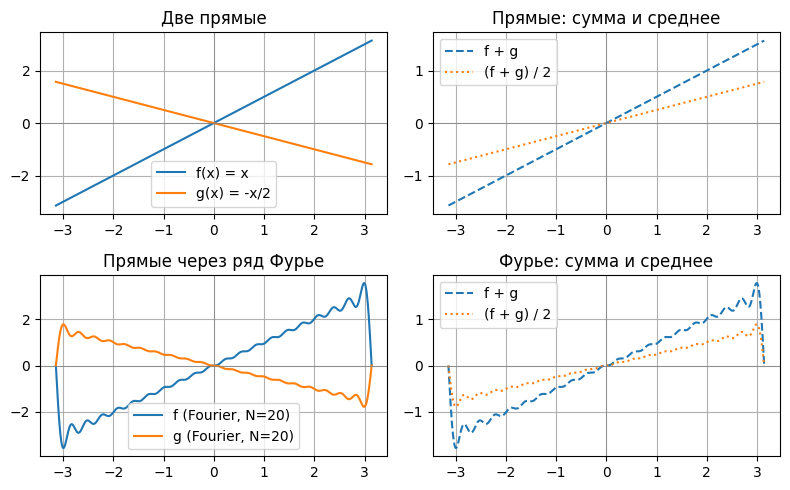

In [22]:
import numpy as np
from matplotlib import pyplot

x = np.linspace(-np.pi, np.pi, 1000)

f_line = x
g_line = -x / 2
sum_line = f_line + g_line
avg_line = (f_line + g_line) / 2

N = 20
f = np.zeros_like(x)
g = np.zeros_like(x)
for n in range(1, N + 1):
    coef = (-1)**(n + 1) / n * np.sin(n * x)
    f += 2 * coef
    g += -1 * coef
sum_fg = f + g
avg_fg = (f + g) / 2

fig, ax = pyplot.subplots(2, 2, figsize=(8, 5))

ax[0, 0].plot(x, f_line, label='f(x) = x')
ax[0, 0].plot(x, g_line, label='g(x) = -x/2')
ax[0, 0].set_title('Две прямые')
ax[0, 0].legend()
ax[0, 0].grid(True)

ax[0, 1].plot(x, sum_line, label='f + g', linestyle='--')
ax[0, 1].plot(x, avg_line, label='(f + g) / 2', linestyle=':')
ax[0, 1].set_title('Прямые: сумма и среднее')
ax[0, 1].legend()
ax[0, 1].grid(True)

ax[1, 0].plot(x, f, label='f (Fourier, N=20)')
ax[1, 0].plot(x, g, label='g (Fourier, N=20)')
ax[1, 0].set_title('Прямые через ряд Фурье')
ax[1, 0].legend()
ax[1, 0].grid(True)

ax[1, 1].plot(x, sum_fg, label='f + g', linestyle='--')
ax[1, 1].plot(x, avg_fg, label='(f + g) / 2', linestyle=':')
ax[1, 1].set_title('Фурье: сумма и среднее')
ax[1, 1].legend()
ax[1, 1].grid(True)

for a in ax.flat:
    a.axhline(0, color='gray', linewidth=0.5)
    a.axvline(0, color='gray', linewidth=0.5)

pyplot.tight_layout()
pyplot.show()

## Прямые

$$f(x) = x$$

$$g(x) = -\frac{x}{2}$$

$$f(x) + g(x) = \frac{x}{2}$$

$$\frac{f(x) + g(x)}{2} = \frac{x}{4}$$

---

## Ряды Фурье на $[-\pi, \pi]$

$$f(x) = x = 2\sum_{n=1}^{\infty} \frac{(-1)^{n+1}}{n}\sin(nx)$$

$$g(x) = -\frac{x}{2} = -\sum_{n=1}^{\infty} \frac{(-1)^{n+1}}{n}\sin(nx)$$

$$f(x) + g(x) = \sum_{n=1}^{\infty} \frac{(-1)^{n+1}}{n}\sin(nx)$$

$$\frac{f(x) + g(x)}{2} = \frac{1}{2}\sum_{n=1}^{\infty} \frac{(-1)^{n+1}}{n}\sin(nx)$$

---

## Частичная сумма (то, что считается в коде, $N=20$)

$$f_N(x) = 2\sum_{n=1}^{N} \frac{(-1)^{n+1}}{n}\sin(nx)$$

$$g_N(x) = -\sum_{n=1}^{N} \frac{(-1)^{n+1}}{n}\sin(nx)$$


#### Second step is arifmetic sums for different functions

$$f(x, y) = \frac{1}{2}x + y$$ $$g(x) = x$$ $$\tilde{g}(x, y) = g(x) = x$$ $$f(x, y) + \tilde{g}(x, y) = \frac{1}{2}x + y + x = \frac{3}{2}x + y$$ $$\frac{f(x, y) + \tilde{g}(x, y)}{2} = \frac{3}{4}x + \frac{y}{2}$$


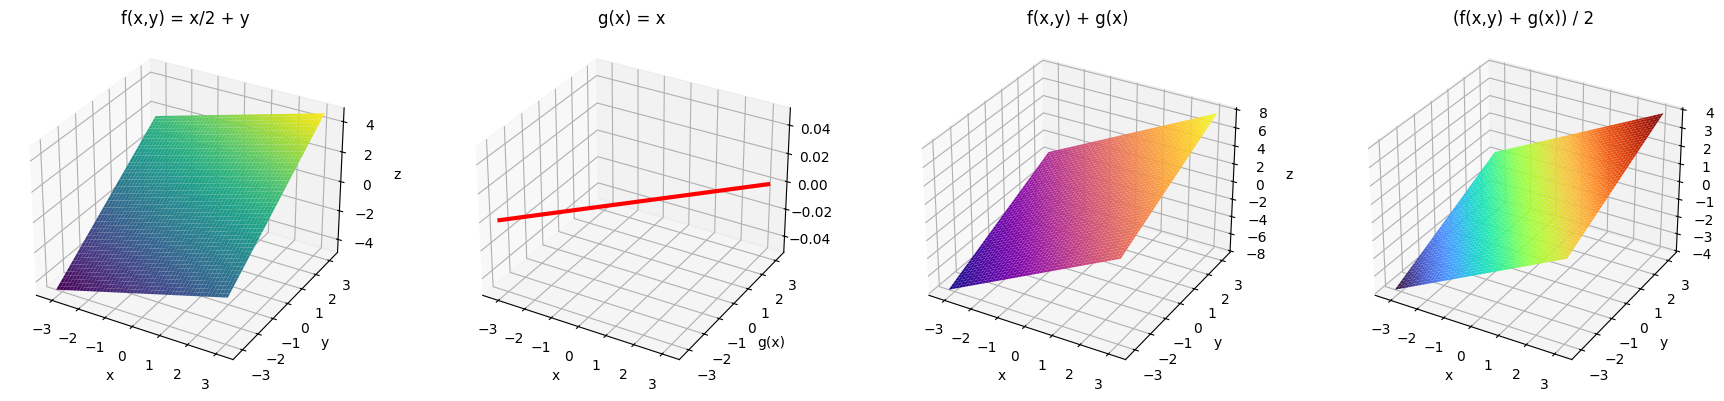

In [26]:
import numpy
from numpy import pi, linspace, meshgrid
from matplotlib import pyplot

figure = getattr(pyplot, "figure")
tight_layout = getattr(pyplot, "tight_layout")
show = getattr(pyplot, "show")

xs = linspace(-pi, pi, 200)
ys = linspace(-pi, pi, 200)
X, Y = meshgrid(xs, ys)

f_xy = X / 2 + Y
g_x = xs
g_xy = X

sum_fg = f_xy + g_xy
avg_fg = sum_fg / 2

fig = figure(figsize=(18, 4))

ax1 = getattr(fig, "add_subplot")(1, 4, 1, projection="3d")
getattr(ax1, "plot_surface")(X, Y, f_xy, cmap="viridis")
getattr(ax1, "set_title")("f(x,y) = x/2 + y")
getattr(ax1, "set_xlabel")("x")
getattr(ax1, "set_ylabel")("y")
getattr(ax1, "set_zlabel")("z")

ax2 = getattr(fig, "add_subplot")(1, 4, 2, projection="3d")
getattr(ax2, "plot")(xs, g_x, color="red", linewidth=3)
getattr(ax2, "set_title")("g(x) = x")
getattr(ax2, "set_xlabel")("x")
getattr(ax2, "set_ylabel")("g(x)")
getattr(ax2, "grid")(True)

ax3 = getattr(fig, "add_subplot")(1, 4, 3, projection="3d")
getattr(ax3, "plot_surface")(X, Y, sum_fg, cmap="plasma")
getattr(ax3, "set_title")("f(x,y) + g(x)")
getattr(ax3, "set_xlabel")("x")
getattr(ax3, "set_ylabel")("y")
getattr(ax3, "set_zlabel")("z")

ax4 = getattr(fig, "add_subplot")(1, 4, 4, projection="3d")
getattr(ax4, "plot_surface")(X, Y, avg_fg, cmap="turbo")
getattr(ax4, "set_title")("(f(x,y) + g(x)) / 2")
getattr(ax4, "set_xlabel")("x")
getattr(ax4, "set_ylabel")("y")
getattr(ax4, "set_zlabel")("z")

tight_layout()
show()